In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
dataset = pd.read_csv('clean_dataset.csv')

In [4]:
dataset.shape

(68114, 86)

In [5]:
dataset.drop(columns=['dwgt_r', 'ld_ster',
'ld_chor'], inplace=True)

In [6]:
cols = ['combgest',
 'gestrec10',
 'gestrec3',
 'lmpused',
 'oegest_comb',
 'oegest_r10',
 'oegest_r3']
for col in cols:
    print(col, sorted(dataset[col].unique()))
    

combgest [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
gestrec10 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
gestrec3 [1, 2, 3]
lmpused [nan]
oegest_comb [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
oegest_r10 [2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
oegest_r3 [1, 2, 3]


In [7]:
dataset['combgest'] = dataset['combgest'].replace(99, pd.NA)
cleaned_dataset = dataset.dropna(subset=['combgest']).copy()
print(cleaned_dataset['combgest'].isnull().sum())

0


# Defining Preterm Target

In [9]:
cleaned_dataset['preterm'] = (cleaned_dataset['combgest']<37).astype(int)

In [10]:
cleaned_dataset['preterm'].value_counts()

0    58295
1     9715
Name: preterm, dtype: int64

In [11]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'obgest_flg', 'compgst_imp']
cleaned_dataset = cleaned_dataset.drop(columns=target_leakage_cols)

In [12]:
cleaned_dataset.shape

(68010, 76)

# Drop columns with >80% missing values

In [14]:
missing_90_cols = [col for col in cleaned_dataset.columns if cleaned_dataset[col].isnull().mean()>0.9]

In [15]:
cleaned_dataset = cleaned_dataset.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", cleaned_dataset.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'lmpused']
New shape: (68010, 70)


# Visualizing the preterm and not-preterm data

In [16]:
cleaned_dataset['preterm'].value_counts()

0    58295
1     9715
Name: preterm, dtype: int64

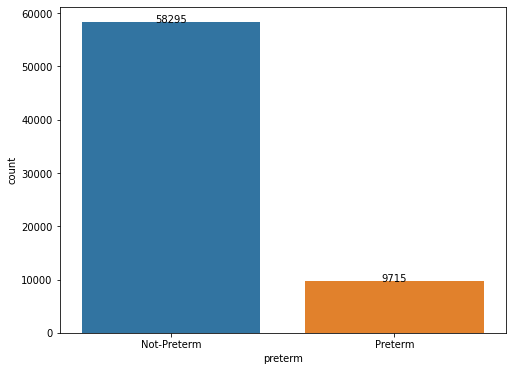

In [17]:
import seaborn as sns
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=cleaned_dataset, x='preterm')
plt.xticks([0, 1], ['Not-Preterm', 'Preterm'])
for p in ax.patches:
    # print(p)
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.savefig('BeforeSplitting.png', dpi=300)
plt.show()

In [18]:
cleaned_dataset.shape

(68010, 70)

In [43]:
unknown_code_map = {
    'mbstate_rec' : 3,'meduc' : 9,'fagecomb' : 99, 'fagerec11': 11, 'frace31': 99,'frace6': 9,'frace15': 99,'feduc': 9,'priorlive': 99,'priordead': 99,
    'priorterm': 99,'lbo_rec' : 9,'tbo_rec': 9,'illb_r': 999,'illb_r11': 99,'ilop_r': 999,
    'ilop_r11': 99,'ilp_r': 999,'ilp_r11': 99,'precare5': 5,'previs_rec': 12, 'cig_0': 99,'cig_1': 99,'cig_2': 99,'cig_3': 99,
    'cig0_r': 6,'cig1_r': 6,'cig2_r': 6,'cig3_r': 6,'m_ht_in': 99,
    'bmi': 99.9,'bmi_r': 9,'pwgt_r': 999,'dwgt_r':999,'wtgain': 99,'wtgain_rec': 9,'rf_cesarn': 99,'no_risks': 9,'no_infec': 9,
    'setorder_r': 9,'dlmp_mm': 99,'dlmp_yy': 9999      
    
}

In [48]:
cleaned_dataset.isnull().sum()[cleaned_dataset.isnull().sum()>0]

Series([], dtype: int64)

# Train Test split

In [19]:
X = cleaned_dataset.drop(columns=['preterm'])  # your features
y = cleaned_dataset['preterm']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Visualizing the Preterm vs Not_Preterm in Train and Test

# Using Seaborn

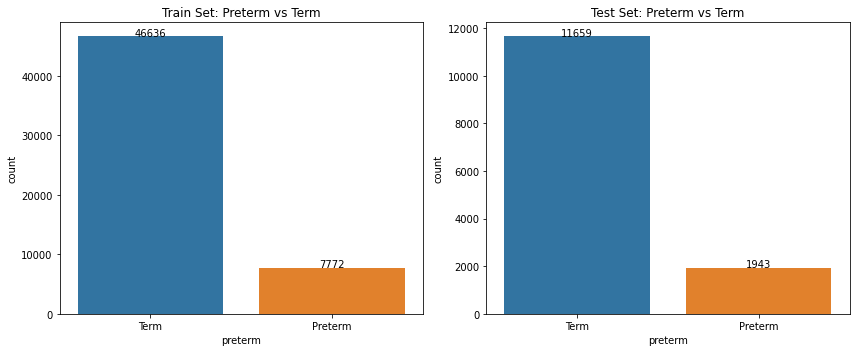

In [20]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Term','Preterm'])
axes[0].set_title('Train Set: Preterm vs Term')
for p in axes[0].patches:
    # print(p)
    height = p.get_height()
    axes[0].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')

    

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Term','Preterm'])
axes[1].set_title('Test Set: Preterm vs Term')
for p in axes[1].patches:
    # print(p)
    height = p.get_height()
    axes[1].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.tight_layout()
plt.show()


In [21]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
corr = X_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs


[('mager14', 'mager', 0.9482029945527047),
 ('mager9', 'mager', 0.9718199602315704),
 ('mager9', 'mager14', 0.9712654507814591),
 ('mrace6', 'mrace31', 0.9198933732681766),
 ('mrace15', 'mrace31', 0.8951652126303197),
 ('mrace15', 'mrace6', 0.9670595738916027),
 ('fagerec11', 'fagecomb', 0.9425423471227553),
 ('frace6', 'frace31', 0.9236026170351281),
 ('frace15', 'frace31', 0.9981406288744871),
 ('frace15', 'frace6', 0.9424603065166295),
 ('illb_r11', 'illb_r', 0.9987231740208955),
 ('ilop_r11', 'ilop_r', 0.9992978829630798),
 ('ilp_r11', 'ilp_r', 0.9989923517119145),
 ('cig_1', 'cig_0', 0.9937844108337238),
 ('cig_2', 'cig_0', 0.9936177715071682),
 ('cig_2', 'cig_1', 0.9987986962024713),
 ('cig_3', 'cig_0', 0.8989158784117193),
 ('cig_3', 'cig_1', 0.9029379552143216),
 ('cig_3', 'cig_2', 0.9032317659701966),
 ('cig0_r', 'cig_0', 0.9934161927015898),
 ('cig0_r', 'cig_1', 0.9851205316972458),
 ('cig0_r', 'cig_2', 0.9842360017020102),
 ('cig0_r', 'cig_3', 0.8906177711802814),
 ('cig1_r'

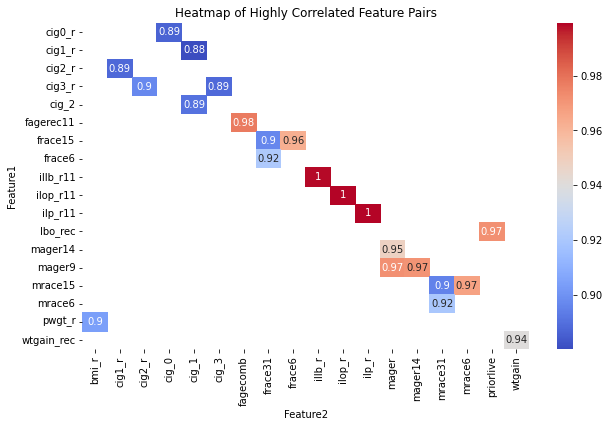

In [90]:
# Convert to a matrix
df_pairs = pd.DataFrame(corr_pairs, columns=['Feature1', 'Feature2', 'Correlation'])

# Pivot into matrix form
corr_matrix = df_pairs.pivot(index='Feature1', columns='Feature2', values='Correlation')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap of Highly Correlated Feature Pairs")

plt.show()

In [22]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']


In [23]:
X_train = X_train.drop(columns=cols_to_drop)
print(X_train.shape)


(54408, 51)


In [24]:
X_test = X_test.drop(columns = cols_to_drop)
print(X_test.shape)

(13602, 51)


In [25]:
X_train = X_train.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])

In [26]:
X_train = X_train.drop(columns=['no_risks', 'no_infec', 'cig_rec'])


In [27]:
X_test = X_test.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])
X_test = X_test.drop(columns=['no_risks', 'no_infec', 'cig_rec'])


In [28]:
print(X_train.shape)
print(X_test.shape)

(54408, 42)
(13602, 42)


# Data Preprocessing

# Step 1: Continuous / Numeric Features Preprocessing   (12)

In [29]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)


12

In [30]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [31]:
unknown_code_map.items()

dict_items([('fagecomb', 99), ('priorlive', 99), ('priordead', 99), ('priorterm', 99), ('illb_r', 999), ('ilop_r', 999), ('ilp_r', 999), ('m_ht_in', 99), ('bmi', 99.9), ('wtgain', 99), ('rf_cesarn', 99)])

In [32]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in cleaned_dataset.columns:
        X_train[col] = X_train[col].replace(code, pd.NA)

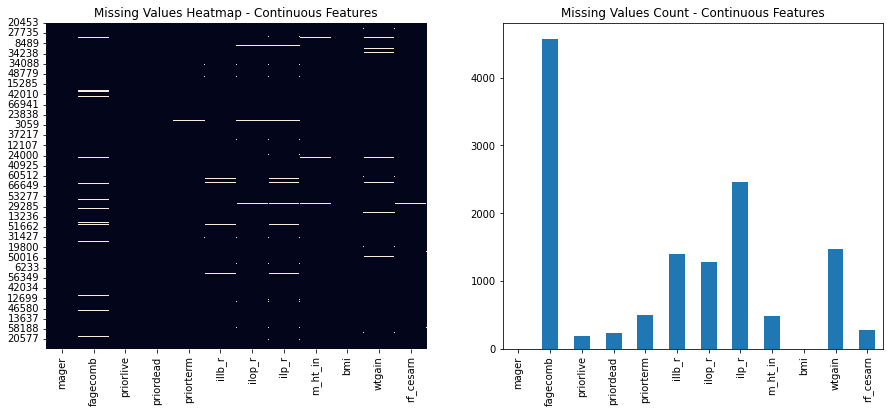

In [33]:

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(X_train[numeric_continuous_features].isna(), cbar=False)
plt.title("Missing Values Heatmap - Continuous Features")
# plt.show()

plt.subplot(1, 2, 2)
X_train[numeric_continuous_features].isna().sum().plot(kind='bar')
plt.title("Missing Values Count - Continuous Features")
plt.show()


In [106]:
# for col in unknown_code_map.keys():
#     if col in X_train.columns:
#         # Replace unknown codes with NaN first (already done)
#         median_value = X_train[col].median()  # compute median ignoring NaN
#         X_train[col] = X_train[col].fillna(median_value)

In [34]:
(X_train[numeric_continuous_features].isnull().sum()/X_train.shape[0])*100

mager        0.000000
fagecomb     8.406852
priorlive    0.362079
priordead    0.426408
priorterm    0.928172
illb_r       2.586017
ilop_r       2.370975
ilp_r        4.537936
m_ht_in      0.893251
bmi          0.000000
wtgain       2.716512
rf_cesarn    0.507278
dtype: float64

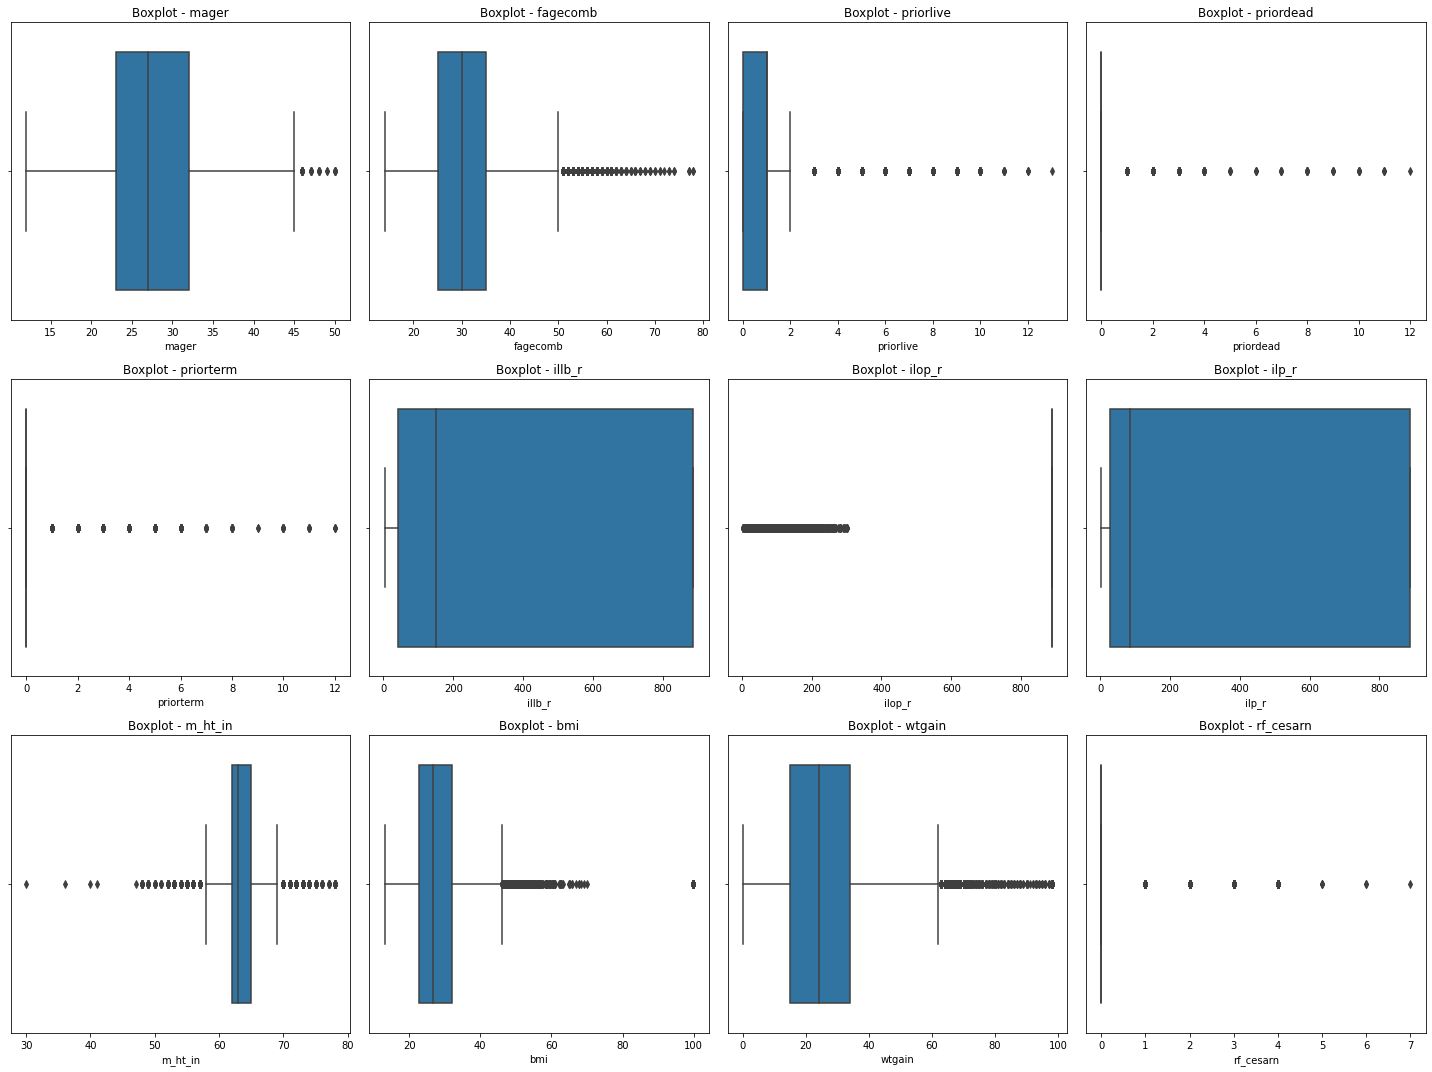

In [79]:

num_features = len(numeric_continuous_features)
cols = 4
rows = (num_features + cols - 1) // cols  

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))  
axes = axes.flatten() 
for i, col in enumerate(numeric_continuous_features):
    sns.boxplot(x=X_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot - {col}")


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [33]:
numeric_values = X_train.select_dtypes(include=['number']).columns
print(numeric_values)
# for i in numeric_values:
#     print(i, X_train[i].unique())

Index(['mager', 'mrace6', 'dmar', 'meduc', 'fagecomb', 'frace6', 'feduc',
       'priorlive', 'priordead', 'priorterm', 'tbo_rec', 'illb_r', 'ilop_r',
       'ilp_r', 'precare5', 'previs_rec', 'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn', 'dplural',
       'setorder_r'],
      dtype='object')


# Step 2: Ordinal Features Preprocessing (11)

In [41]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec']
len(ordinal_features)

10

# Step 3: One-Hot Features (19)

In [38]:

all_features = X_train.columns.tolist()
one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
print(one_hot_features)
len(one_hot_features)

['rf_ppterm', 'frace6', 'ip_syph', 'rf_cesar', 'dmar', 'ip_gon', 'rf_ehype', 'rf_phype', 'rf_pdiab', 'ip_hepb', 'rf_gdiab', 'ip_chlam', 'rf_inftr', 'mrace6', 'ip_hepc', 'mar_p', 'rf_fedrg', 'rf_ghype', 'rf_artec']


19

In [39]:
missing_pct = X_train[ordinal_features].isna().mean() * 100
print("Missing percentage:\n", missing_pct)


Missing percentage:
 meduc         0.0
feduc         0.0
cig0_r        0.0
cig1_r        0.0
cig2_r        0.0
cig3_r        0.0
precare5      0.0
previs_rec    0.0
dplural       0.0
tbo_rec       0.0
setorder_r    0.0
dtype: float64


In [40]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# for col in ordinal_features:
#     sns.countplot(x=X_train[col])
#     plt.title(f"Distribution - {col}")
#     plt.show()



In [48]:
X_train[numeric_continuous_features].isna().sum()


mager           0
fagecomb     4574
priorlive     197
priordead     232
priorterm     505
illb_r       1407
ilop_r       1290
ilp_r        2469
m_ht_in       486
bmi             0
wtgain       1478
rf_cesarn     276
dtype: int64

# Build Preprocessing Pipeline

In [49]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [50]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = 'passthrough'

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

In [51]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numeric_continuous_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('onehot', categorical_pipeline, one_hot_features)
    ]
)

In [52]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [53]:
X_train_processed

array([[ 0.38089601, -0.20935994,  1.01183183, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.55232851,  2.63100453,  3.65617726, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.92378855,  1.49485874,  5.41907421, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.72376102,  0.07467651, -0.75106513, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2094635 , -0.35137816, -0.75106513, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.58092354,  0.07467651, -0.75106513, ...,  0.        ,
         1.        ,  0.        ]])

In [54]:
X_test_processed

array([[-0.13340151, -0.35137816, -0.75106513, ...,  0.        ,
         1.        ,  0.        ],
       [-1.16199654, -0.06734172,  1.01183183, ...,  0.        ,
         1.        ,  0.        ],
       [-0.13340151, -0.20935994, -0.75106513, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.72376102,  0.50073118,  0.13038335, ...,  0.        ,
         1.        ,  0.        ],
       [-1.16199654, -0.91945106, -0.75106513, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.55232851,  0.6427494 ,  0.13038335, ...,  0.        ,
         1.        ,  0.        ]])

# Train a Baseline Classifier (Random Forest)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [58]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [59]:
y_pred = clf.predict(X_test_processed)

In [60]:
# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     11659
           1       0.72      0.17      0.28      1943

    accuracy                           0.87     13602
   macro avg       0.80      0.58      0.61     13602
weighted avg       0.86      0.87      0.84     13602



In [61]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11526   133]
 [ 1604   339]]


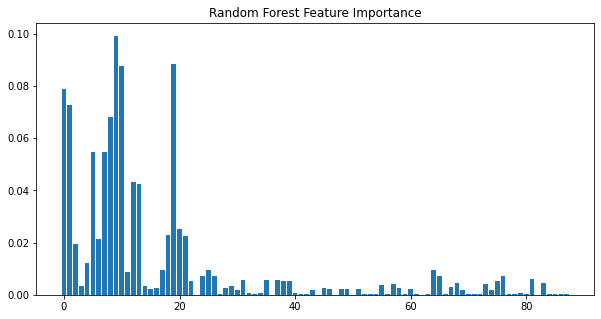

In [62]:
import numpy as np
import matplotlib.pyplot as plt

feature_importances = clf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importances)), feature_importances)
plt.title("Random Forest Feature Importance")
plt.show()


# Hyperparameter Tuning (Randomized Search / Grid Search)

In [65]:
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [66]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator = rf,
    param_distributions = param_dist,
    n_iter = 10,
    scoring = 'f1',                 # improve minority class
    cv = 2,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

rf_random.fit(X_train_processed, y_train)

print("Best parameters:", rf_random.best_params_)


Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}


In [68]:
best_model = rf_random.best_estimator_
y_pred_best = best_model.predict(X_test_processed)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


[[8247 3412]
 [ 649 1294]]
              precision    recall  f1-score   support

           0       0.93      0.71      0.80     11659
           1       0.27      0.67      0.39      1943

    accuracy                           0.70     13602
   macro avg       0.60      0.69      0.60     13602
weighted avg       0.83      0.70      0.74     13602

